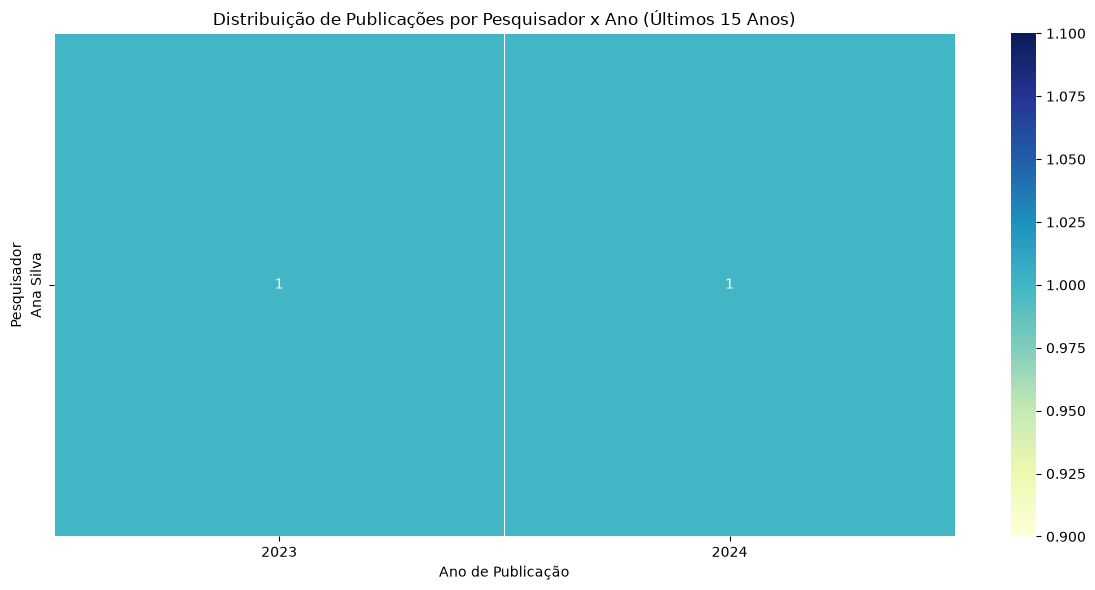

In [3]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns

# 1. Carrega os dados do arquivo Parquet
caminho = (
    Path("artigos.parquet")
    if Path("artigos.parquet").exists()
    else Path("../data/exemplo/artigos.parquet")
)
df = pd.read_parquet(caminho)

# 2. Identifica colunas e filtra os últimos 15 anos
col_pesquisador = (
    "pesquisador" if "pesquisador" in df.columns else "nome_completo"
)
col_valor = (
    "titulo_artigo" if "titulo_artigo" in df.columns else df.columns[0]
)

ano_max = df["ano"].max()
df_filtrado = df[df["ano"] >= (ano_max - 15)]

# 3. Construção da Tabela Dinâmica
matriz = df_filtrado.pivot_table(
    index=col_pesquisador,
    columns="ano",
    values=col_valor,
    aggfunc="count",
    fill_value=0,
)

# 4. Renderização do Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)
plt.title("Distribuição de Publicações por Pesquisador x Ano (Últimos 15 Anos)")
plt.xlabel("Ano de Publicação")
plt.ylabel("Pesquisador")
plt.tight_layout()
plt.show()

**Interpretação do Mapa de Calor:**
* **Intensidade das Cores:** As células com tons mais escuros (azul/verde fechado) indicam os picos de produtividade de cada pesquisador em determinado ano.
* **Células Claras/Zerar (0):** As células amarelas ou com valor 0 indicam períodos de inatividade do docente ou ausência de registros no sistema naquele ano específico.
* **Padrão Histórico:** Permite identificar rapidamente se a produção científica se manteve constante ou se concentrou em anos específicos.